In [111]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import os
import logging

from pathlib import Path

import dotenv

import torch
from torchvision.transforms.v2 import Compose
from torchvision.transforms.v2 import GaussianBlur, Compose

from huggingface_hub import login


from brain_image.data import load_image_from_path
from brain_image.configs import get_device
from brain_image.model import NICEModel
from brain_image.utils import setup

setup()

In [ ]:
cp_path = "logs/nice/version_38/checkpoints/nice-epoch=24-val_top1_acc=0.3790.ckpt"
nice_model = NICEModel.load_checkpoint(cp_path, compile=False)
device = get_device()
dtype = torch.float16

loader = nice_model.data_module.test_dataloader()
ex_batch = next(iter(loader))
img_latent = ex_batch["img_latent"]
eeg_data = ex_batch["eeg_data"]
img_path = ex_batch["img_path"]

/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
from brain_image.reconstruction import ReconstructionPipeline


pipe = ReconstructionPipeline.from_stable_diffusion()

In [ ]:
images = torch.stack([load_image_from_path(Path(p)) for p in img_path])[:4]
print("Images loaded", images.shape, images.max(), images.min(), images.dtype)


ll_pp_img = pipe.preprocess_low_level_image(images)
pp_img = pipe.preprocess_conditioning_image(images)
print("Images preprocessed", pp_img.shape, pp_img.dtype, pp_img.max(), pp_img.min())
print(
    "Low level images preprocessed",
    ll_pp_img.shape,
    ll_pp_img.dtype,
    ll_pp_img.max(),
    ll_pp_img.min(),
)

Images loaded torch.Size([4, 3, 500, 500]) tensor(255, dtype=torch.uint8) tensor(0, dtype=torch.uint8) torch.uint8


AttributeError: 'ReconstructionPipeline' object has no attribute 'preprocess_low_level_image'

Shapes (500, 500, 3), (224, 224, 3), (512, 512, 3)
Max 1.0, 1.056, 1.035
Min 0.0, -0.019, -0.025


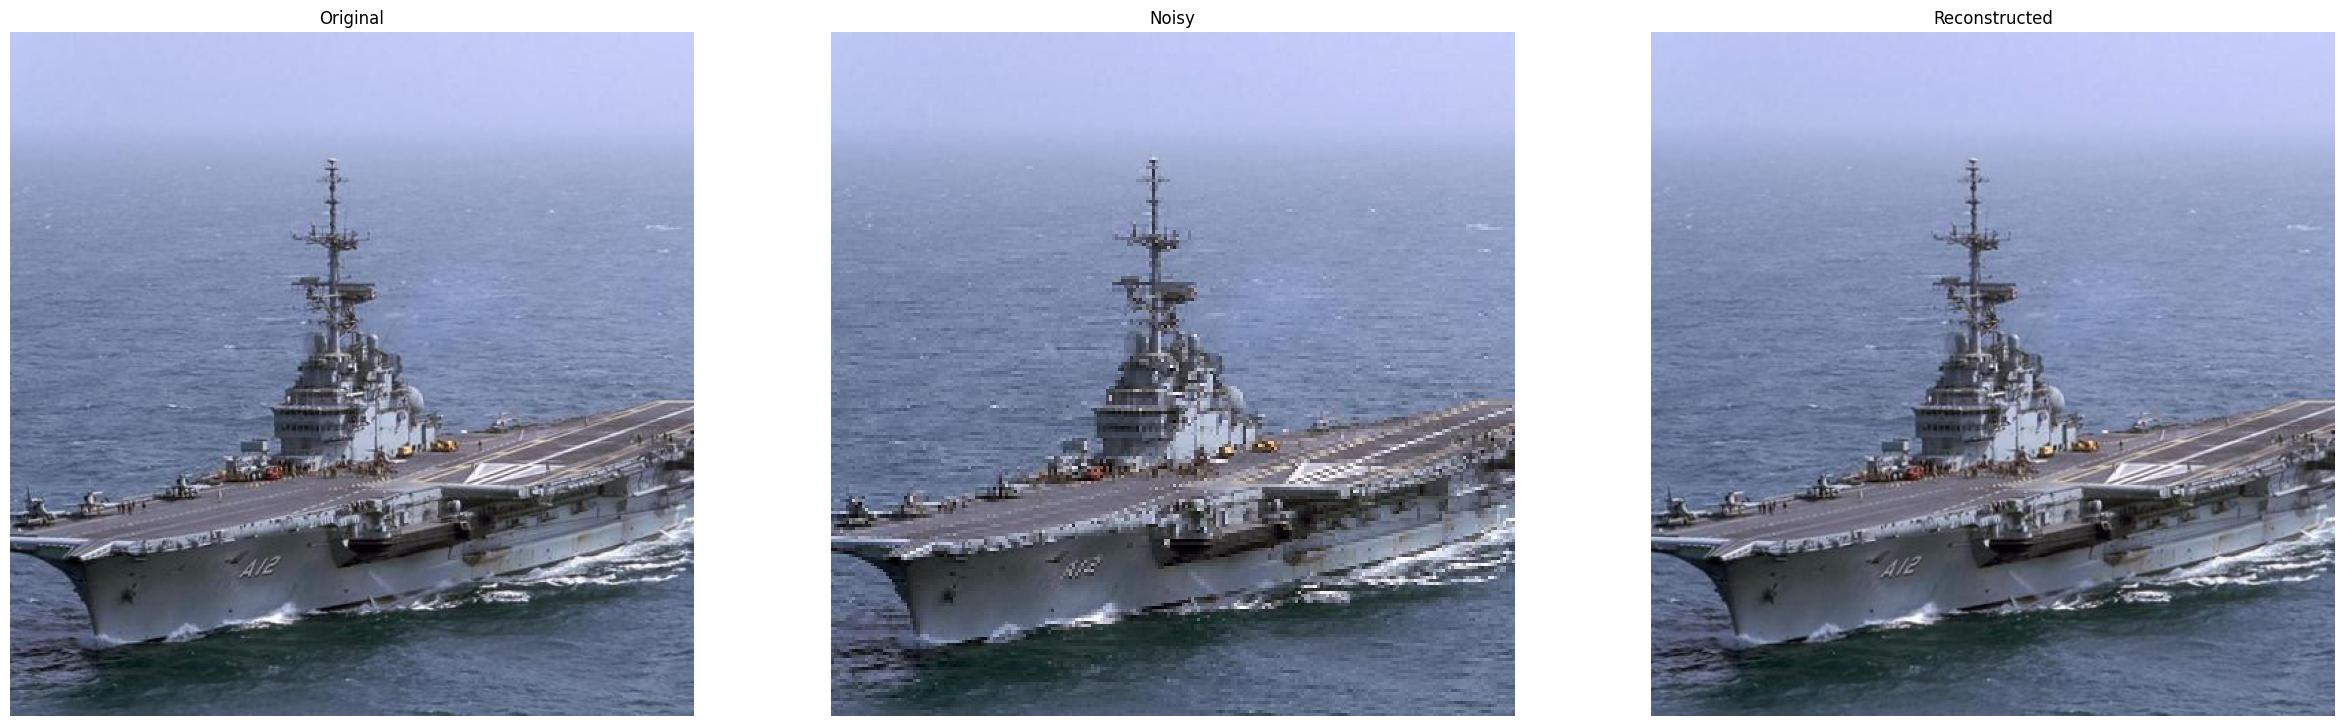

In [ ]:
from brain_image.utils import show_image


show_image(
    images[0],
    pp_img[0],
    ll_pp_img[0],
    transforms=["normalize", "unstandardize", "none"],
    verbose=True,
    titles=["Original", "Noisy", "Reconstructed"],
)

Shapes (500, 500, 3), (500, 500, 3)
Max 1.0, 0.988
Min 0.0, 0.094


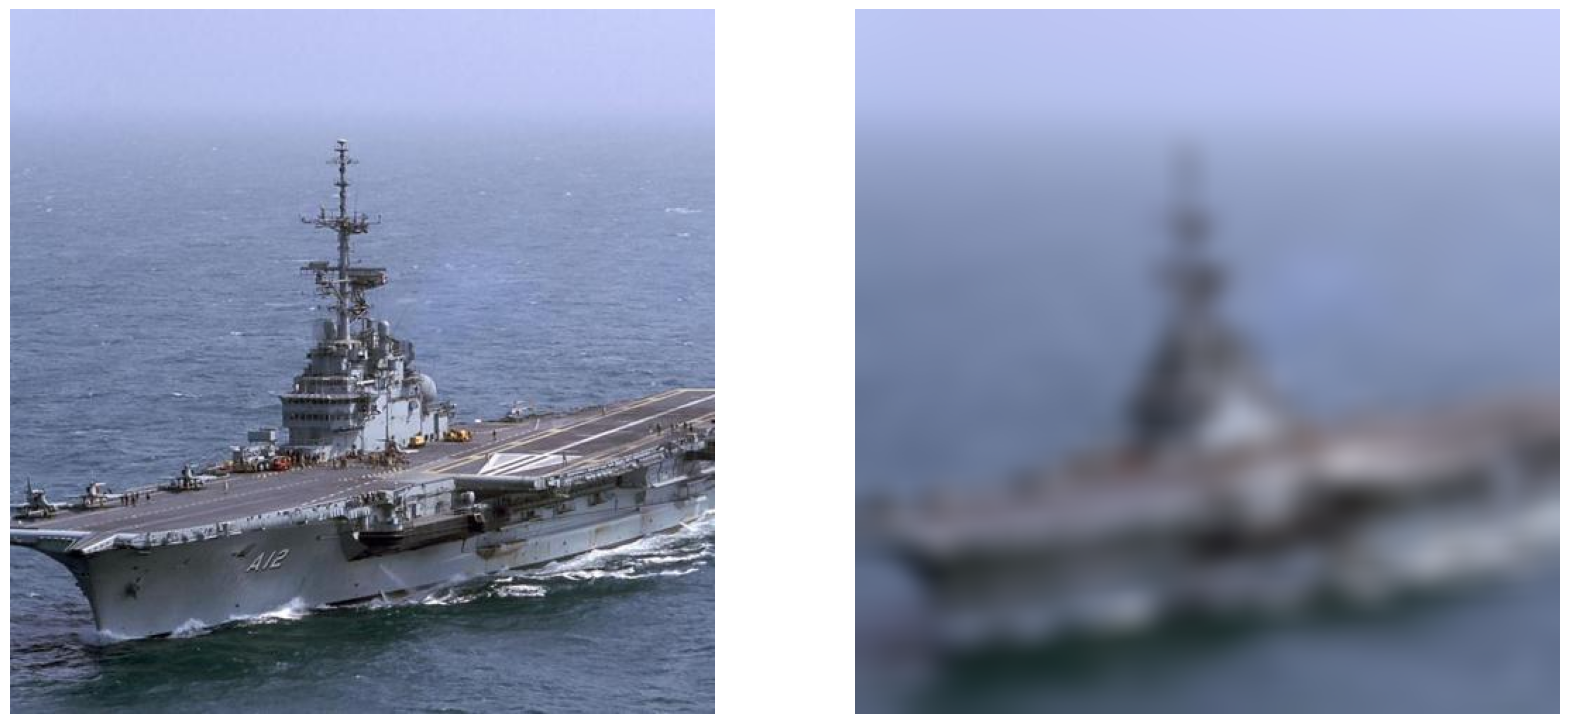

In [ ]:
# We create an artificially terrible image for low level

noise_pipe = Compose(
    [
        GaussianBlur(kernel_size=(33, 33), sigma=10.0),
    ]
)

noisy_images = noise_pipe(images)

show_image(
    images[0], noisy_images[0], transforms=["normalize", "normalize"], verbose=True
)

In [116]:
with torch.no_grad():
    print("Images loaded", images.shape, images.max(), images.min(), images.dtype)
    print(
        "Noisy images loaded",
        noisy_images.shape,
        noisy_images.max(),
        noisy_images.min(),
        noisy_images.dtype,
    )

    conditioning_images = images.to(device)
    low_level_images = noisy_images.to(device)

    conditioning_latent = pipe.encode_conditioning_image(conditioning_images)
    low_level_latent = pipe.encode_low_level_image(low_level_images)

    reconstruction = pipe.reconstruct_latents(
        conditioning_latent,
        low_image_latent=low_level_latent,
        noise_strength=0.5,
        guidance_scale=6,
        num_inference_steps=50,
    )

Images loaded torch.Size([4, 3, 500, 500]) tensor(255, dtype=torch.uint8) tensor(0, dtype=torch.uint8) torch.uint8
Noisy images loaded torch.Size([4, 3, 500, 500]) tensor(252, dtype=torch.uint8) tensor(4, dtype=torch.uint8) torch.uint8


In [ ]:
with torch.no_grad():
    print("Images loaded", images.shape, images.max(), images.min(), images.dtype)
    print(
        "Noisy images loaded",
        noisy_images.shape,
        noisy_images.max(),
        noisy_images.min(),
        noisy_images.dtype,
    )

    reconstruction = pipe.reconstruct_target(
        images,
        noisy_images,
        noise_strength=1.0,
        guidance_scale=6,
        num_inference_steps=50,
    )

Images loaded torch.Size([4, 3, 500, 500]) tensor(255, dtype=torch.uint8) tensor(0, dtype=torch.uint8) torch.uint8
Noisy images loaded torch.Size([4, 3, 500, 500]) tensor(252, dtype=torch.uint8) tensor(4, dtype=torch.uint8) torch.uint8


Shapes (224, 224, 3), (512, 512, 3)
Max 1.056, 0.966
Min -0.019, 0.073


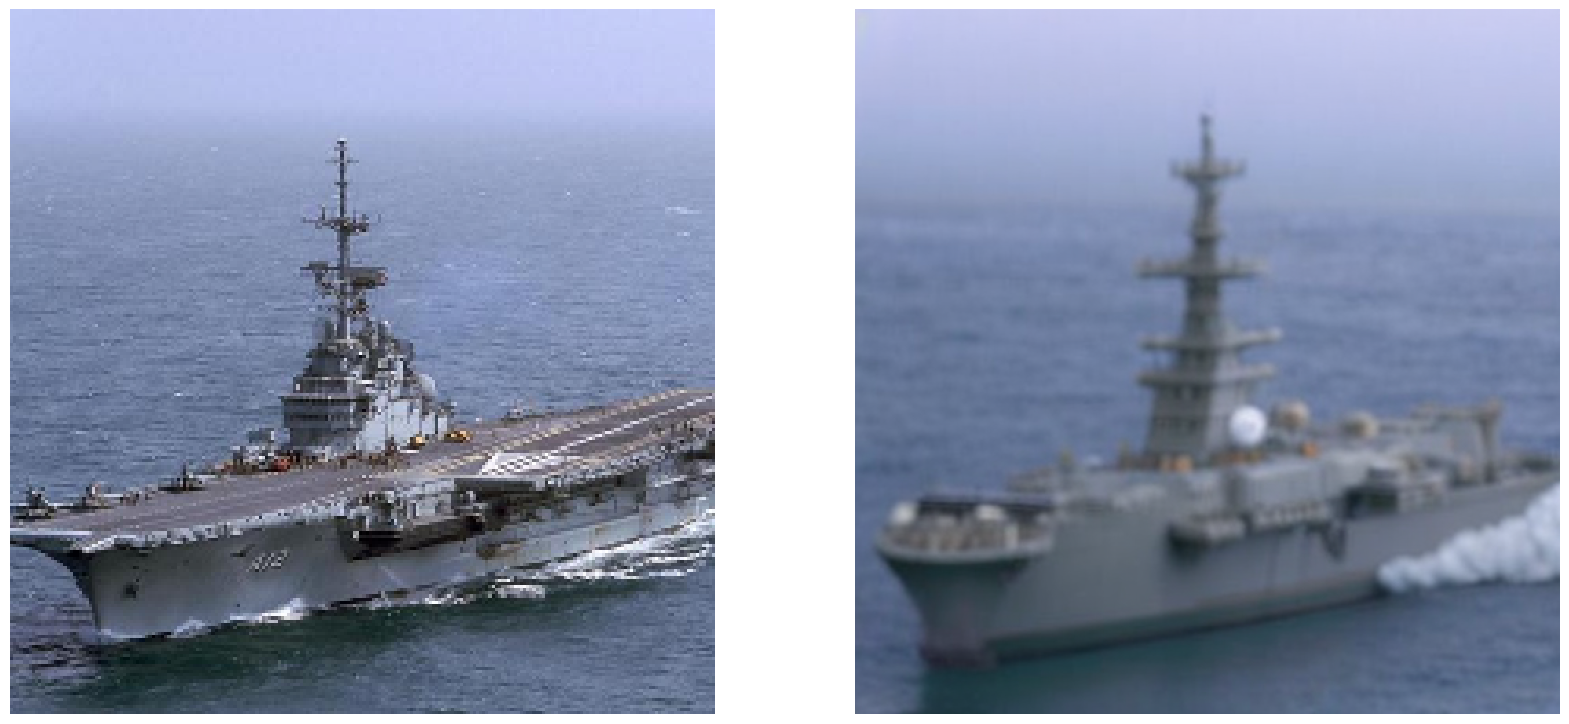

Shapes (224, 224, 3), (512, 512, 3)
Max 0.955, 0.994
Min -0.049, 0.0


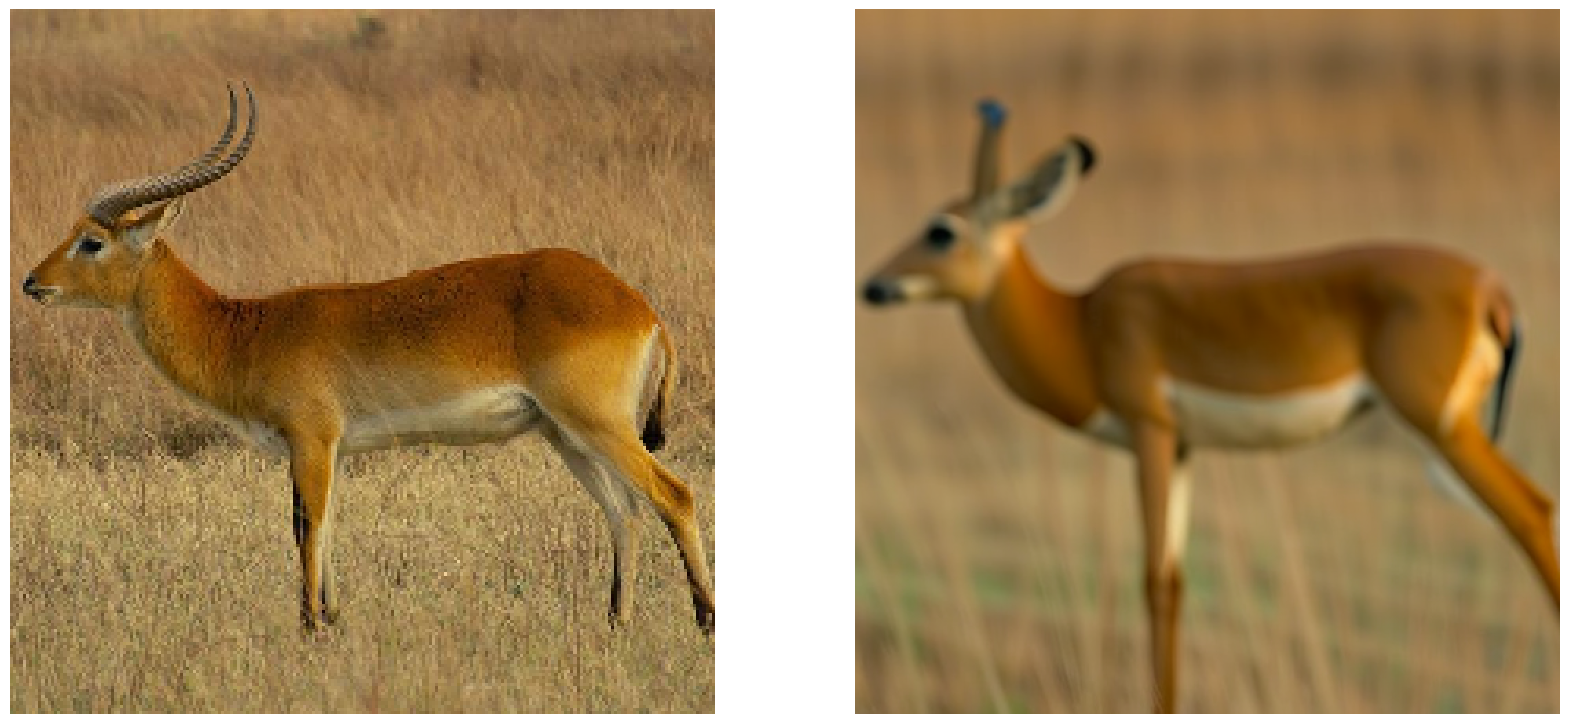

Shapes (224, 224, 3), (512, 512, 3)
Max 1.023, 0.996
Min -0.078, 0.002


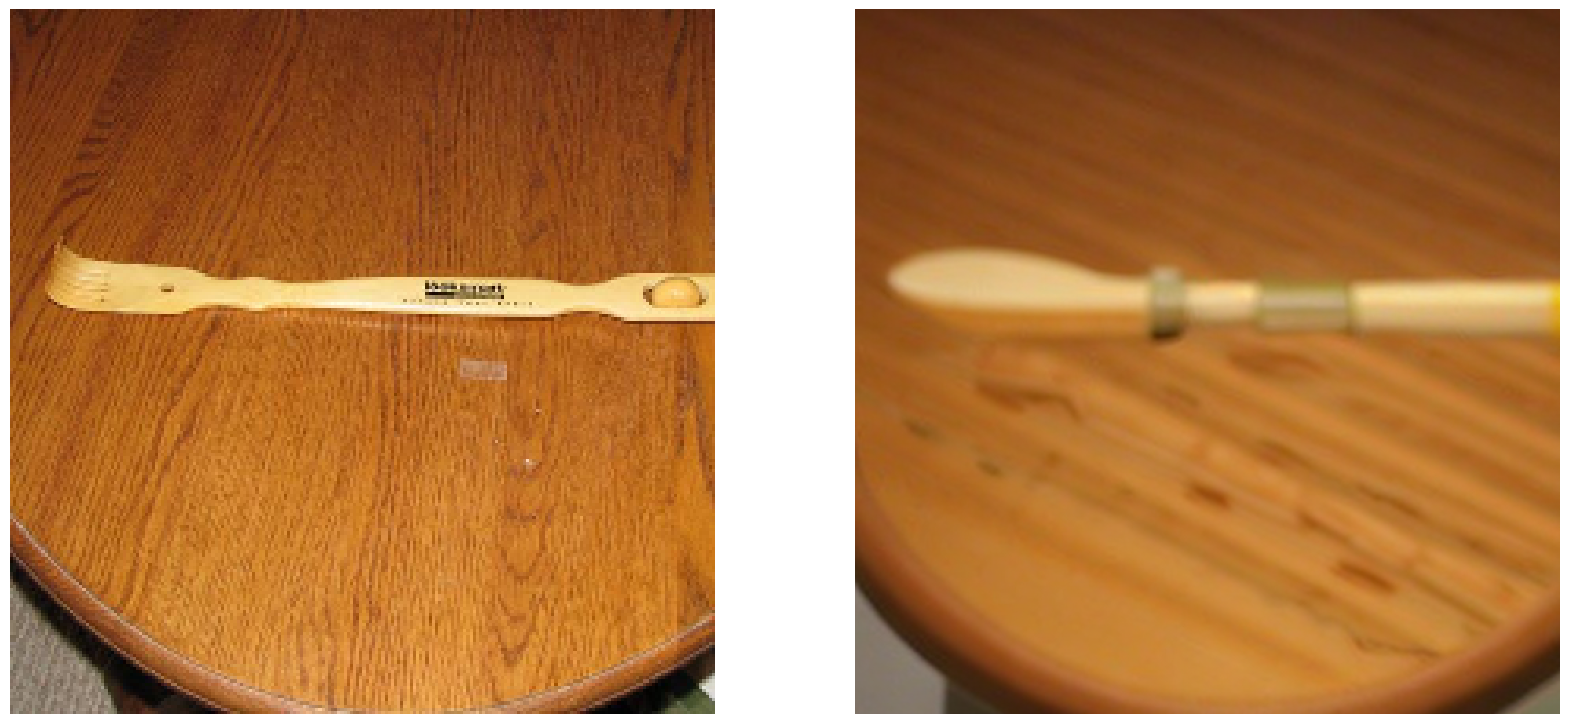

Shapes (224, 224, 3), (512, 512, 3)
Max 1.046, 0.991
Min -0.038, 0.0


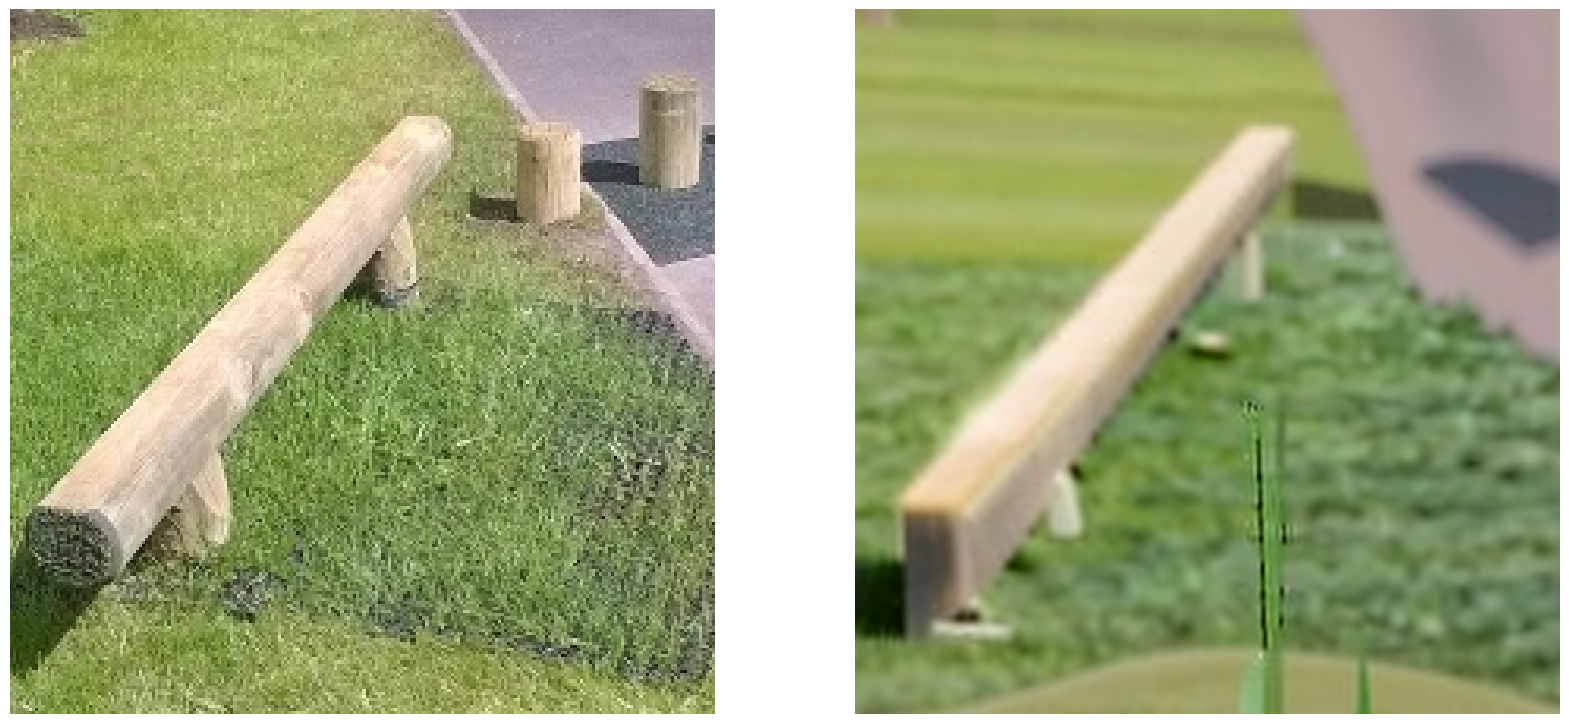

In [117]:
for i in range(4):
    show_image(
        pp_img[i], reconstruction[i], transforms=["unstandardize", "none"], verbose=True
    )

In [ ]:
# Sweep over noise strength, guidance scale, and num inference steps

RUN_EXPERIMENTS = False

noise_strengths = [0.2, 0.4, 0.6, 0.8, 1.0]
guidance_scales = [2.5, 5, 7.5, 10]
num_inference_steps = [25, 50, 75]

exp_num = 0

output_path = Path("experiments/reconstruction_target_sweep")
output_path.mkdir(parents=True, exist_ok=True)

if RUN_EXPERIMENTS:
    for noise_strength in noise_strengths:
        for guidance_scale in guidance_scales:
            for num_step in num_inference_steps:
                exp_num += 1
                print(f"================================================")
                print(f"Experiment {exp_num}:")
                print(f"Noise strength: {noise_strength}")
                print(f"Guidance scale: {guidance_scale}")
                print(f"Number of inference steps: {num_step}")
                print(f"================================================")

                with torch.no_grad():
                    reconstruction = pipe.reconstruct_target(
                        images,
                        noisy_images,
                        noise_strength=noise_strength,
                        guidance_scale=guidance_scale,
                        num_inference_steps=num_step,
                    )
                    show_image(
                        images[0],
                        noisy_images[0],
                        reconstruction[0],
                        transforms=["normalize", "normalize", "none"],
                        titles=[
                            "Target (CLIP conditioning)",
                            "Noisy (Low-level image)",
                            "Reconstructed",
                        ],
                        verbose=False,
                        save_path=output_path
                        / f"reconstruction_{exp_num}-ns{noise_strength}-gs{guidance_scale}-is{num_step}.png",
                        show_fig=False,
                        suptitle=f"Noise strength: {noise_strength}, Guidance scale: {guidance_scale}, Number of inference steps: {num_step}",
                    )

Experiment 1:
Noise strength: 0.2
Guidance scale: 2.5
Number of inference steps: 25
Experiment 2:
Noise strength: 0.2
Guidance scale: 2.5
Number of inference steps: 50
Experiment 3:
Noise strength: 0.2
Guidance scale: 2.5
Number of inference steps: 75
Experiment 4:
Noise strength: 0.2
Guidance scale: 5
Number of inference steps: 25
Experiment 5:
Noise strength: 0.2
Guidance scale: 5
Number of inference steps: 50
Experiment 6:
Noise strength: 0.2
Guidance scale: 5
Number of inference steps: 75
Experiment 7:
Noise strength: 0.2
Guidance scale: 7.5
Number of inference steps: 25
Experiment 8:
Noise strength: 0.2
Guidance scale: 7.5
Number of inference steps: 50
Experiment 9:
Noise strength: 0.2
Guidance scale: 7.5
Number of inference steps: 75
Experiment 10:
Noise strength: 0.2
Guidance scale: 10
Number of inference steps: 25
Experiment 11:
Noise strength: 0.2
Guidance scale: 10
Number of inference steps: 50
Experiment 12:
Noise strength: 0.2
Guidance scale: 10
Number of inference steps: 7